In [ ]:
# ===== 0. Colab GPU 확인 =====
!python -V
!nvidia-smi

Python 3.12.13
Sat Apr 11 18:59:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r "/content/drive/MyDrive/10flowers" .

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.10.0+cu128
True
Tesla T4


In [ ]:
%cd /content
!git clone https://github.com/taco-group/MWFormer.git
%cd /content/MWFormer

!pip install -q timm opencv-python-headless scikit-image tqdm gdown

/content
Cloning into 'MWFormer'...
remote: Enumerating objects: 286, done.
remote: Counting objects: 100% (286/286), done.
remote: Compressing objects: 100% (266/266), done.
remote: Total 286 (delta 29), reused 265 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (286/286), 24.33 MiB | 34.61 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/MWFormer


In [ ]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, ToTensor, Normalize

class FlowersMWDataset(Dataset):
    def __init__(self, root, lq_folder="LQ1", gt_folder="GT"):
        self.root = root
        self.input_dir = os.path.join(root, lq_folder)
        self.gt_dir = os.path.join(root, gt_folder)

        self.names = sorted(
            [f for f in os.listdir(self.input_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))],
            key=lambda x: int(os.path.splitext(x)[0]) if os.path.splitext(x)[0].isdigit() else x
        )

        self.transform_input = Compose([
            ToTensor(),
            Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        self.transform_gt = Compose([ToTensor()])

    def _resize_like_repo(self, input_img, gt_img):
        wd_new, ht_new = input_img.size

        if ht_new > wd_new and ht_new > 1024:
            wd_new = int(np.ceil(wd_new * 1024 / ht_new))
            ht_new = 1024
        elif ht_new <= wd_new and wd_new > 1024:
            ht_new = int(np.ceil(ht_new * 1024 / wd_new))
            wd_new = 1024

        wd_new = int(16 * np.ceil(wd_new / 16.0))
        ht_new = int(16 * np.ceil(ht_new / 16.0))

        input_img = input_img.resize((wd_new, ht_new), Image.Resampling.LANCZOS)
        gt_img = gt_img.resize((wd_new, ht_new), Image.Resampling.LANCZOS)
        return input_img, gt_img

    def __getitem__(self, idx):
        name = self.names[idx]

        input_img = Image.open(os.path.join(self.input_dir, name)).convert("RGB")
        gt_img = Image.open(os.path.join(self.gt_dir, name)).convert("RGB")

        input_img, gt_img = self._resize_like_repo(input_img, gt_img)

        input_tensor = self.transform_input(input_img)
        gt_tensor = self.transform_gt(gt_img)

        return input_tensor, gt_tensor, name

    def __len__(self):
        return len(self.names)

In [ ]:
import os
os.makedirs("/content/weights", exist_ok=True)

In [ ]:
# 1) 다운로드 도구 설치
!pip -q install gdown
# 2) /content/weights 생성 + Google Drive에서 바로 다운로드
import os
import gdown
import zipfile
import tarfile
import glob
import shutil

os.makedirs("/content/weights", exist_ok=True)

# README의 Pre-Trained Models 링크
file_id = "12tP7I1wm7sSI7ZlLBZz78tlrIV-JhsWP"
url = f"https://drive.google.com/uc?id={file_id}"

# 일단 확장자 없이 저장
download_path = "/content/weights/mwformer_pretrained"
gdown.download(url, download_path, quiet=False)

print("다운로드 완료:", download_path)
print("현재 /content/weights 목록:")
for p in sorted(glob.glob("/content/weights/*")):
    print(p)

Downloading...
From (original): https://drive.google.com/uc?id=12tP7I1wm7sSI7ZlLBZz78tlrIV-JhsWP
From (redirected): https://drive.google.com/uc?id=12tP7I1wm7sSI7ZlLBZz78tlrIV-JhsWP&confirm=t&uuid=d4212b68-5a02-4f38-aef4-a5f8d188c060
To: /content/weights/mwformer_pretrained
100%|██████████| 1.40G/1.40G [00:17<00:00, 79.9MB/s]

다운로드 완료: /content/weights/mwformer_pretrained
현재 /content/weights 목록:
/content/weights/mwformer_pretrained


In [ ]:
# 3) 압축파일이면 자동 해제, 아니면 그대로 둠
import os
import zipfile
import tarfile
import glob

download_path = "/content/weights/mwformer_pretrained"
extract_dir = "/content/weights/extracted"

os.makedirs(extract_dir, exist_ok=True)

if zipfile.is_zipfile(download_path):
    print("zip 압축파일입니다. 해제합니다.")
    with zipfile.ZipFile(download_path, "r") as zf:
        zf.extractall(extract_dir)

elif tarfile.is_tarfile(download_path):
    print("tar 계열 압축파일입니다. 해제합니다.")
    with tarfile.open(download_path, "r:*") as tf:
        tf.extractall(extract_dir)

else:
    print("압축파일이 아닙니다. 단일 파일일 가능성이 큽니다.")

print("\n최종 파일 목록:")
for p in sorted(glob.glob("/content/weights/**/*", recursive=True)):
    if os.path.isfile(p):
        print(p)

zip 압축파일입니다. 해제합니다.

최종 파일 목록:
/content/weights/extracted/MWFormer_L/backbone
/content/weights/extracted/MWFormer_L/style_filter
/content/weights/extracted/MWFormer_real/backbone
/content/weights/extracted/MWFormer_real/style_filter
/content/weights/extracted/pretrained feature extraction network/style_filter.pth
/content/weights/mwformer_pretrained


In [ ]:
import os
import glob

candidates = []
for ext in ["*.pth", "*.pt", "*.ckpt", "*.pth.tar"]:
    candidates.extend(glob.glob(f"/content/weights/**/*{ext[1:]}", recursive=True))

print("weight 후보:")
for p in sorted(candidates):
    print(p)

weight 후보:
/content/weights/extracted/pretrained feature extraction network/style_filter.pth


In [ ]:
!file /content/weights/extracted/MWFormer_L/backbone


/content/weights/extracted/MWFormer_L/backbone.pth: cannot open `/content/weights/extracted/MWFormer_L/backbone.pth' (No such file or directory)


In [ ]:
import torch
from model.EncDec import Network_top
from model.style_filter64 import StyleFilter_Top

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_clean_state_dict(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        ckpt = ckpt["state_dict"]
    ckpt = {k.replace("module.", ""): v for k, v in ckpt.items()}
    model.load_state_dict(ckpt, strict=True)
    return model

backbone_path = "/content/weights/extracted/MWFormer_L/backbone"      # 실제 경로로 수정
stylefilter_path = "/content/weights/extracted/MWFormer_L/style_filter"  # 실제 경로로 수정

net = Network_top().to(device)
style_filter = StyleFilter_Top().to(device)

net = load_clean_state_dict(net, backbone_path)
style_filter = load_clean_state_dict(style_filter, stylefilter_path)

net.eval()
style_filter.eval()

print("model loaded")

model loaded


In [ ]:
!rm -rf "/content/results_LQ3"

In [ ]:
import os
from torchvision.utils import save_image
from utils_val import calculate_psnr, calculate_ssim

data_root = "/content/data/10flowers"
lq_folder = "LQ3"   # LQ2, LQ3로 바꿔가며 테스트
save_dir = f"/content/results_{lq_folder}"
os.makedirs(save_dir, exist_ok=True)

dataset = FlowersMWDataset(root=data_root, lq_folder=lq_folder, gt_folder="GT")
loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=2)

psnr_list = []
ssim_list = []

with torch.no_grad():
    for input_image, gt, name in loader:
        input_image = input_image.to(device)
        gt = gt.to(device)

        feature_vec = style_filter(input_image)
        pred = net(input_image, feature_vec).clamp(0, 1)

        pred_img = pred[0].permute(1, 2, 0).cpu()
        gt_img = gt[0].permute(1, 2, 0).cpu()

        psnr = calculate_psnr(255 * gt_img, 255 * pred_img)
        ssim = calculate_ssim(255 * gt_img, 255 * pred_img)

        psnr_list.append(psnr)
        ssim_list.append(ssim)

        save_image(pred[0], os.path.join(save_dir, name[0]))

print(f"{lq_folder} 평균 PSNR: {sum(psnr_list)/len(psnr_list):.4f}")
print(f"{lq_folder} 평균 SSIM: {sum(ssim_list)/len(ssim_list):.4f}")
print(f"결과 저장 위치: {save_dir}")

LQ3 평균 PSNR: 14.4141
LQ3 평균 SSIM: 0.6605
결과 저장 위치: /content/results_LQ3


input mean: 0.1948826164007187
pred mean : 0.18977080285549164
mean abs diff(input,pred): 0.008791347034275532
max abs diff(input,pred): 0.19023483991622925


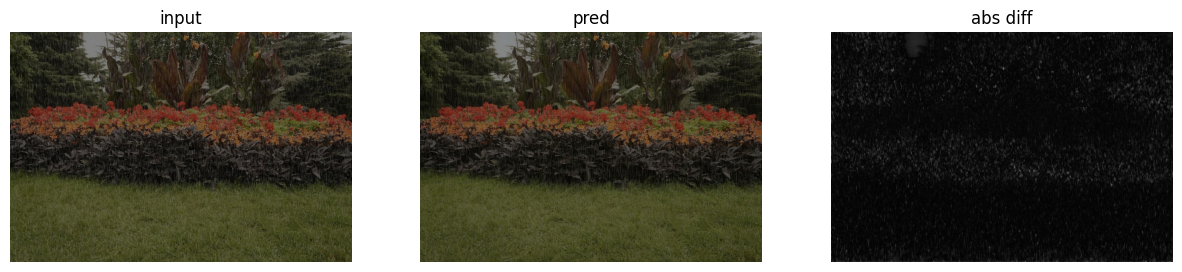

In [ ]:
import torch
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

input_image, gt, name = dataset[0]   # 네 dataset 객체 기준
x = input_image.unsqueeze(0).to(device)

with torch.no_grad():
    feat = style_filter(x)
    pred = net(x, feat).clamp(0, 1)

inp_vis = ((input_image + 1) / 2).clamp(0, 1)   # input은 [-1,1] -> [0,1]
pred_vis = pred[0].cpu()

print("input mean:", inp_vis.mean().item())
print("pred mean :", pred_vis.mean().item())
print("mean abs diff(input,pred):", (inp_vis - pred_vis).abs().mean().item())
print("max abs diff(input,pred):", (inp_vis - pred_vis).abs().max().item())

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(inp_vis.permute(1,2,0))
ax[0].set_title("input")
ax[1].imshow(pred_vis.permute(1,2,0))
ax[1].set_title("pred")
ax[2].imshow((inp_vis - pred_vis).abs().mean(0), cmap="gray")
ax[2].set_title("abs diff")
for a in ax:
    a.axis("off")
plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch

baseline_psnr = []
baseline_ssim = []

for input_image, gt, name in loader:
    # input_image: normalized [-1,1]
    inp_vis = ((input_image + 1) / 2).clamp(0, 1)
    gt_vis = gt.clamp(0, 1)

    inp_np = inp_vis[0].permute(1,2,0).cpu().numpy()
    gt_np = gt_vis[0].permute(1,2,0).cpu().numpy()

    psnr = peak_signal_noise_ratio(gt_np, inp_np, data_range=1.0)
    ssim = structural_similarity(gt_np, inp_np, channel_axis=2, data_range=1.0)

    baseline_psnr.append(psnr)
    baseline_ssim.append(ssim)

print("Input baseline PSNR:", sum(baseline_psnr)/len(baseline_psnr))
print("Input baseline SSIM:", sum(baseline_ssim)/len(baseline_ssim))

Input baseline PSNR: 12.555502638329882
Input baseline SSIM: 0.607958


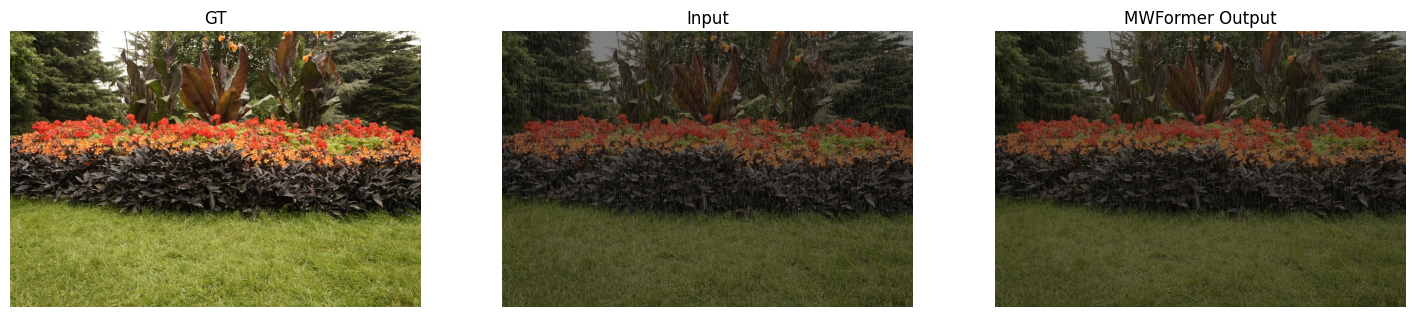

In [ ]:
import matplotlib.pyplot as plt

input_image, gt, name = dataset[0]
x = input_image.unsqueeze(0).to(device)

with torch.no_grad():
    feat = style_filter(x)
    pred = net(x, feat).clamp(0, 1)

inp_vis = ((input_image + 1) / 2).clamp(0, 1)
gt_vis = gt.clamp(0, 1)
pred_vis = pred[0].cpu()

fig, ax = plt.subplots(1, 3, figsize=(18,6))
ax[0].imshow(gt_vis.permute(1,2,0))
ax[0].set_title("GT")
ax[1].imshow(inp_vis.permute(1,2,0))
ax[1].set_title("Input")
ax[2].imshow(pred_vis.permute(1,2,0))
ax[2].set_title("MWFormer Output")

for a in ax:
    a.axis("off")
plt.show()